# EmotionCLIP-ReID — Landmark Build Notebook

Notebook độc lập này chỉ chuẩn bị landmark/anatomy artifact cho FER2013 và RAF-DB. Chạy notebook này trước các notebook train; sau khi build xong, notebook train chỉ đọc `manifest_anatomy.jsonl` và không chạy detector lại.

Mỗi lần build có `LANDMARK_RUN_ID` theo ngày giờ. Artifact dataset được cache riêng theo hash manifest, model, schema và tham số jitter; log/audit/ảnh preview của lần build nằm trong `outputs/landmark_build/<LANDMARK_RUN_ID>/`.


## 0. Clone hoặc cập nhật source `old_branch`

Generator landmark nằm trong branch `old_branch` của EmotionCLIP-ReID. Cell này không clone một detector repo thứ hai; MediaPipe chỉ được cài như runtime package và model task được tải một lần.


In [1]:
from pathlib import Path
import os
import subprocess
import sys

# Có thể đặt EMOTIONCLIP_REPO nếu notebook chạy ngoài thư mục repo.
# Nếu không đặt, notebook tự tìm repo từ thư mục hiện tại và các thư mục cha.
REPO_OVERRIDE = os.environ.get('EMOTIONCLIP_REPO', '').strip()
if REPO_OVERRIDE:
    REPO_DIR = Path(REPO_OVERRIDE).expanduser().resolve()
else:
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    REPO_DIR = next(
        (candidate for candidate in candidates
         if (candidate / 'train_emotionclip.py').is_file()
         and (candidate / 'utils').is_dir()),
        None,
    )
    if REPO_DIR is None:
        # `/home/...` is valid on JupyterHub Linux only; it becomes
        # `E:\home\...` on Windows and points to the wrong checkout.
        JUPYTER_WORKSPACE = (
            Path('/home/jupyter-hault') if os.name != 'nt'
            else Path.home() / 'jupyter-hault'
        )
        REPO_DIR = JUPYTER_WORKSPACE / 'EmotionCLIP-ReID'
GIT_REPO_URL = 'https://github.com/haulth/EmotionCLIP-ReID.git'
REPO_BRANCH = 'old_branch'

REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
if (REPO_DIR / '.git').exists():
    commands = [
        ['git', '-C', str(REPO_DIR), 'fetch', 'origin', REPO_BRANCH],
        ['git', '-C', str(REPO_DIR), 'checkout', REPO_BRANCH],
        ['git', '-C', str(REPO_DIR), 'pull', '--ff-only', 'origin', REPO_BRANCH],
    ]
else:
    commands = [[
        'git', 'clone', '-b', REPO_BRANCH, '--single-branch', GIT_REPO_URL, str(REPO_DIR)
    ]]
for command in commands:
    print('Running:', ' '.join(command))
    completed = subprocess.run(command, text=True, capture_output=True, check=True)
    if completed.stdout.strip():
        print(completed.stdout.strip())

os.chdir(REPO_DIR)
# Jupyter giữ sys.path của kernel lúc khởi động; đổi cwd không đủ để
# import được `utils.*` từ repo vừa chọn.
repo_path = str(REPO_DIR)
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)
branch = subprocess.check_output(
    ['git', '-C', str(REPO_DIR), 'branch', '--show-current'], text=True
).strip()
assert branch == REPO_BRANCH, f'Expected {REPO_BRANCH}, got {branch}'
REPO = REPO_DIR.resolve()
print('Repo:', REPO)
print('Branch:', branch)
print('Python:', sys.executable)


Running: git -C /home/jupyter-hault/EmotionCLIP-ReID fetch origin old_branch
Running: git -C /home/jupyter-hault/EmotionCLIP-ReID checkout old_branch
Your branch is up to date with 'origin/old_branch'.
Running: git -C /home/jupyter-hault/EmotionCLIP-ReID pull --ff-only origin old_branch
Already up to date.
Repo: /home/jupyter-hault/EmotionCLIP-ReID
Branch: old_branch
Python: /opt/tljh/user/envs/py310/bin/python


## 1. Package và run context

Model task chính thức của MediaPipe được lưu trong `data/models/mediapipe/face_landmarker.task`; nếu file đã tồn tại notebook không tải lại. `FORCE_REBUILD=False` là chế độ bình thường.


In [2]:
from datetime import datetime
from pathlib import Path
import importlib.util
import subprocess
import sys

from utils.notebook_run import timestamped_run_id

if importlib.util.find_spec('mediapipe') is None:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q', 'mediapipe>=0.10.30,<0.11'
    ])

SEED = 42
BUILD_FER2013 = True
BUILD_RAFDB = True
FORCE_REBUILD = False
LANDMARK_JITTER_REPEATS = 4
LANDMARK_JITTER_PIXELS = 2

# ===== PATH DATA CHỈNH TRỰC TIẾP TẠI ĐÂY =====
DATA_DIR = (REPO / 'data').resolve()
FER2013_DATA_DIR = (DATA_DIR / 'hf_fer2013').resolve()
RAFDB_DATA_DIR = (DATA_DIR / 'RAF-DB').resolve()
FER2013_MANIFEST = FER2013_DATA_DIR / 'manifest.jsonl'
FER2013_ANATOMY_MANIFEST = FER2013_DATA_DIR / 'manifest_anatomy.jsonl'
FER2013_ANATOMY_DIR = FER2013_DATA_DIR / 'anatomy_v3'
RAFDB_MANIFEST = RAFDB_DATA_DIR / 'manifest.jsonl'
RAFDB_ANATOMY_MANIFEST = RAFDB_DATA_DIR / 'manifest_anatomy.jsonl'
RAFDB_ANATOMY_DIR = RAFDB_DATA_DIR / 'anatomy_v3'
LANDMARK_MODEL_URL = (
    'https://storage.googleapis.com/mediapipe-models/face_landmarker/'
    'face_landmarker/float16/latest/face_landmarker.task'
)
LANDMARK_MODEL_PATH = DATA_DIR / 'models/mediapipe/face_landmarker.task'
LANDMARK_STARTED_AT = datetime.now().astimezone()
LANDMARK_RUN_ID = timestamped_run_id('landmarks', seed=SEED, now=LANDMARK_STARTED_AT)
LANDMARK_RUN_DIR = REPO / 'outputs' / 'landmark_build' / LANDMARK_RUN_ID
LANDMARK_RUN_DIR.mkdir(parents=True, exist_ok=False)

DATASETS = {
    'fer2013': {
        'data_dir': FER2013_DATA_DIR,
        'manifest': FER2013_MANIFEST,
        'root_dir': FER2013_DATA_DIR / 'images',
        'output_manifest': FER2013_ANATOMY_MANIFEST,
        'artifact_root': FER2013_ANATOMY_DIR,
    },
    'rafdb': {
        'data_dir': RAFDB_DATA_DIR,
        'manifest': RAFDB_MANIFEST,
        'root_dir': RAFDB_DATA_DIR,
        'output_manifest': RAFDB_ANATOMY_MANIFEST,
        'artifact_root': RAFDB_ANATOMY_DIR,
    },
}

print('LANDMARK_RUN_ID:', LANDMARK_RUN_ID)
print('LANDMARK_RUN_DIR:', LANDMARK_RUN_DIR)
print('Model:', LANDMARK_MODEL_PATH)
for name, spec in DATASETS.items():
    print(name, 'data_dir:', spec['data_dir'])
    print(name, 'base manifest:', spec['manifest'])
    print(name, 'anatomy manifest:', spec['output_manifest'])
    print(name, 'anatomy artifacts:', spec['artifact_root'])


LANDMARK_RUN_ID: landmarks-20260721T084504.065233+0700-seed42
LANDMARK_RUN_DIR: /home/jupyter-hault/EmotionCLIP-ReID/outputs/landmark_build/landmarks-20260721T084504.065233+0700-seed42
Model: /home/jupyter-hault/EmotionCLIP-ReID/data/models/mediapipe/face_landmarker.task
fer2013 data_dir: /home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013
fer2013 base manifest: /home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013/manifest.jsonl
fer2013 anatomy manifest: /home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013/manifest_anatomy.jsonl
fer2013 anatomy artifacts: /home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013/anatomy_v3
rafdb data_dir: /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB
rafdb base manifest: /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/manifest.jsonl
rafdb anatomy manifest: /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/manifest_anatomy.jsonl
rafdb anatomy artifacts: /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/anatomy_v3


## 2. Tải model một lần và build cache

Cell này tạo output manifest cho từng dataset được bật. Nếu cache hợp lệ, kết quả trả về `cache_hit=True` và detector không được chạy lại. Nếu đổi model/schema/jitter hoặc muốn ép tạo lại, bật `FORCE_REBUILD=True`.


In [3]:
import json
import shutil
from pathlib import Path

from utils.notebook_landmarks import (
    download_once,
    prepare_cached_landmarks,
    validate_landmark_manifest_layout,
)

model_path, model_downloaded = download_once(LANDMARK_MODEL_URL, LANDMARK_MODEL_PATH)
print('Model downloaded now:', model_downloaded)

enabled = {
    'fer2013': BUILD_FER2013,
    'rafdb': BUILD_RAFDB,
}
build_results = {}

for name, spec in DATASETS.items():
    if not enabled[name]:
        continue
    for key in ('manifest', 'root_dir'):
        if not Path(spec[key]).exists():
            raise FileNotFoundError(f"{name}: missing {key}: {spec[key]}")
    print(f'\n=== Building {name} ===')
    build_log = LANDMARK_RUN_DIR / f'{name}_build.log'
    result = prepare_cached_landmarks(
        repo_root=REPO,
        manifest=spec['manifest'],
        output_manifest=spec['output_manifest'],
        artifact_root=spec['artifact_root'],
        model_path=model_path,
        root_dir=spec['root_dir'],
        jitter_repeats=LANDMARK_JITTER_REPEATS,
        jitter_pixels=LANDMARK_JITTER_PIXELS,
        seed=SEED,
        force_rebuild=FORCE_REBUILD,
        python_executable=sys.executable,
        log_path=build_log,
    )
    layout_report = validate_landmark_manifest_layout(
        spec['output_manifest'], spec['data_dir']
    )
    result['layout_validation'] = layout_report
    build_results[name] = result
    print('cache_hit:', result['cache_hit'])
    print('output_manifest:', result['output_manifest'])
    print('artifacts:', result['artifact_count'], '/', result['record_count'])
    print('layout:', layout_report)

summary_path = LANDMARK_RUN_DIR / 'build_summary.json'
summary_path.write_text(
    json.dumps(
        {
            'run_id': LANDMARK_RUN_ID,
            'started_at': LANDMARK_STARTED_AT.isoformat(),
            'model_path': str(model_path),
            'model_downloaded_now': model_downloaded,
            'force_rebuild': FORCE_REBUILD,
            'jitter_repeats': LANDMARK_JITTER_REPEATS,
            'jitter_pixels': LANDMARK_JITTER_PIXELS,
            'datasets': build_results,
        },
        indent=2,
        ensure_ascii=False,
    ),
    encoding='utf-8',
)
print('Summary:', summary_path)


Model downloaded now: False

=== Building fer2013 ===
cache_hit: True
output_manifest: /home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013/manifest_anatomy.jsonl
artifacts: 35887 / 35887
layout: {'manifest': '/home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013/manifest_anatomy.jsonl', 'data_dir': '/home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013', 'record_count': 35887, 'artifact_count': 35887, 'all_references_relative': True}

=== Building rafdb ===
cache_hit: True
output_manifest: /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/manifest_anatomy.jsonl
artifacts: 15339 / 15339
layout: {'manifest': '/home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/manifest_anatomy.jsonl', 'data_dir': '/home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB', 'record_count': 15339, 'artifact_count': 15339, 'all_references_relative': True}
Summary: /home/jupyter-hault/EmotionCLIP-ReID/outputs/landmark_build/landmarks-20260721T084504.065233+0700-seed42/build_summary.json


## 3. Audit coverage và geometry

Audit được lưu riêng theo `LANDMARK_RUN_ID`. Hãy kiểm tra detection/usable coverage trước khi bật anatomy routing; coverage thấp không được che bằng cách tự điền landmark giả.


In [4]:
import json
import subprocess

audit_results = {}
for name, spec in DATASETS.items():
    if not enabled[name]:
        continue
    audit_path = LANDMARK_RUN_DIR / f'{name}_anatomy_audit_all.json'
    audit_log = LANDMARK_RUN_DIR / f'{name}_audit.log'
    command = [
        sys.executable,
        'tools/audit_anatomy_geometry.py',
        '--manifest', str(spec['output_manifest']),
        '--root-dir', str(spec['root_dir']),
        '--split', 'all',
        '--output', str(audit_path),
    ]
    completed = subprocess.run(
        command,
        cwd=REPO,
        capture_output=True,
        text=True,
        check=False,
    )
    audit_log.write_text(
        (completed.stdout or '') + (completed.stderr or ''),
        encoding='utf-8',
    )
    if completed.stdout:
        print(completed.stdout, end='')
    if completed.returncode:
        raise subprocess.CalledProcessError(
            completed.returncode, command, output=completed.stdout, stderr=completed.stderr
        )
    report = json.loads(audit_path.read_text(encoding='utf-8'))
    audit_results[name] = report
    print(name, 'coverage:', {
        split: payload.get('detection_coverage')
        for split, payload in report.get('splits', {}).items()
    })

(LANDMARK_RUN_DIR / 'audit_summary.json').write_text(
    json.dumps(audit_results, indent=2, ensure_ascii=False), encoding='utf-8'
)
print('Audit summary:', LANDMARK_RUN_DIR / 'audit_summary.json')


wrote=/home/jupyter-hault/EmotionCLIP-ReID/outputs/landmark_build/landmarks-20260721T084504.065233+0700-seed42/fer2013_anatomy_audit_all.json
samples=35887 detected=30536 detection_rate=0.8509
fer2013 coverage: {}
wrote=/home/jupyter-hault/EmotionCLIP-ReID/outputs/landmark_build/landmarks-20260721T084504.065233+0700-seed42/rafdb_anatomy_audit_all.json
samples=15339 detected=13205 detection_rate=0.8609
rafdb coverage: {}
Audit summary: /home/jupyter-hault/EmotionCLIP-ReID/outputs/landmark_build/landmarks-20260721T084504.065233+0700-seed42/audit_summary.json


## 4. Biểu đồ tỷ lệ detection failure

Mỗi dataset có một dashboard gồm tỷ lệ detect/không detect trên toàn bộ dữ liệu, failure rate theo split và cột chồng 100% giữa `Detected`/`Not detected` cho từng lớp emotion. Tổng số mẫu `(n=...)` được ghi dưới tên lớp để tránh diễn giải sai khi các lớp mất cân bằng.


Saved: /home/jupyter-hault/EmotionCLIP-ReID/outputs/landmark_build/landmarks-20260721T084504.065233+0700-seed42/fer2013_landmark_detection_rates.png | overall failure rate: 14.91%


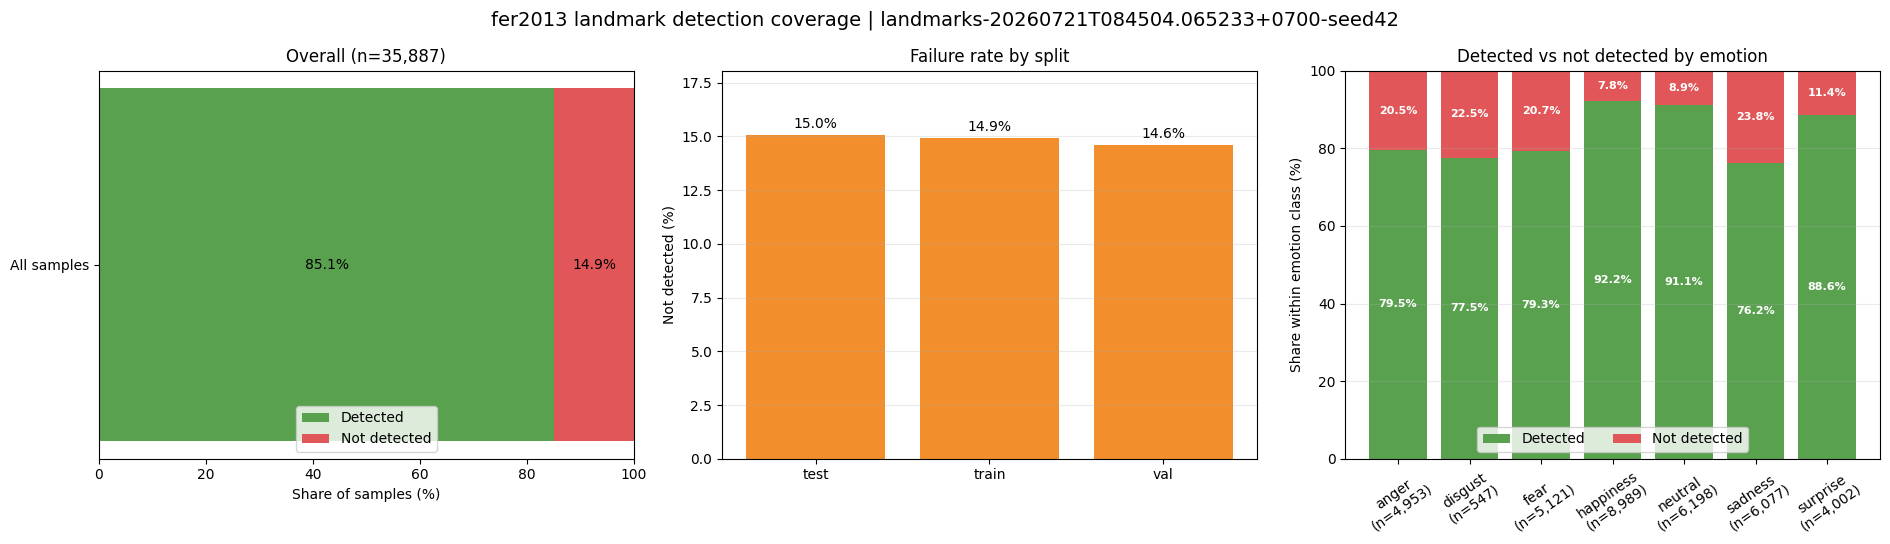

Saved: /home/jupyter-hault/EmotionCLIP-ReID/outputs/landmark_build/landmarks-20260721T084504.065233+0700-seed42/rafdb_landmark_detection_rates.png | overall failure rate: 13.91%


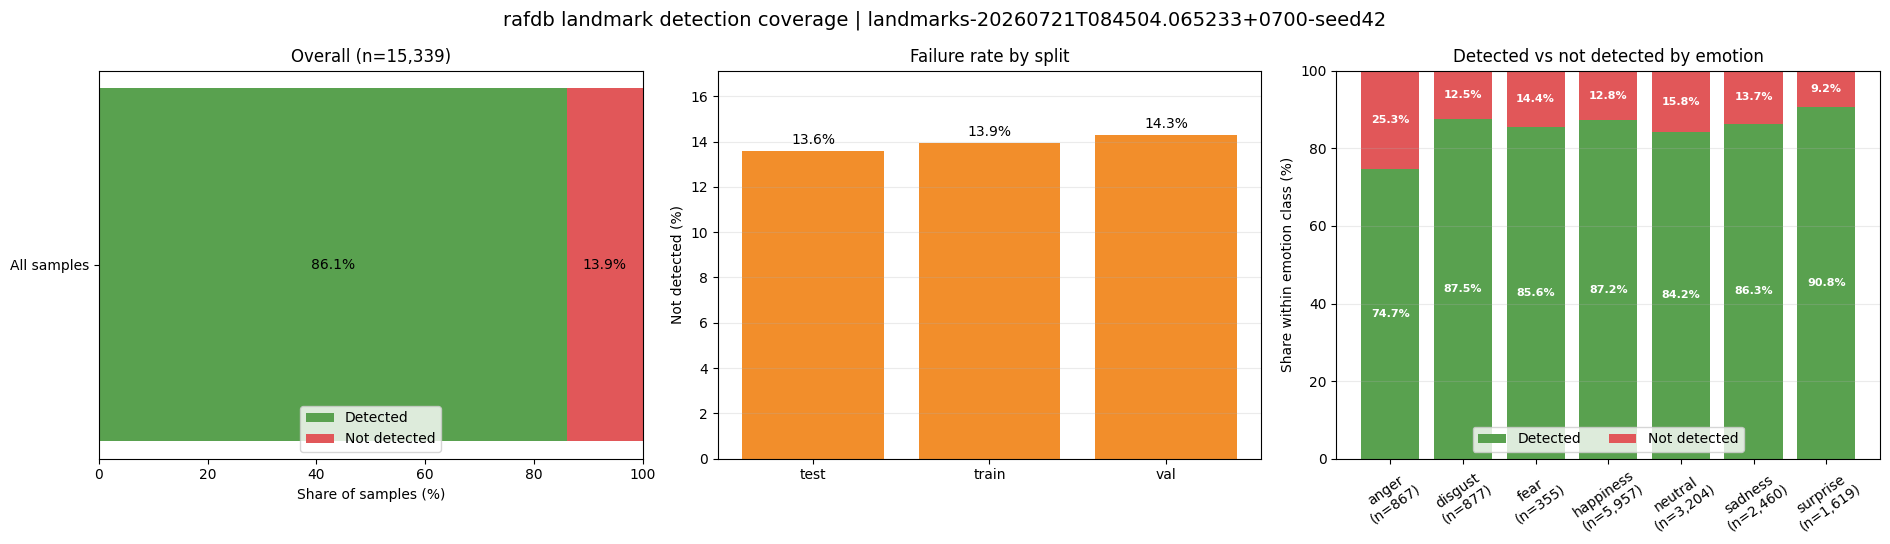

Detection rate summary: /home/jupyter-hault/EmotionCLIP-ReID/outputs/landmark_build/landmarks-20260721T084504.065233+0700-seed42/detection_rate_summary.json


In [8]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

from datasets.anatomy import load_anatomy_artifact
from datasets.emotion_manifest import load_emotion_manifest

detection_rate_reports = {}
detection_chart_paths = {}

for name, spec in DATASETS.items():
    if not enabled[name]:
        continue

    samples = load_emotion_manifest(
        str(spec['output_manifest']), root_dir=str(spec['root_dir']), split=None
    )
    overall = {'total': 0, 'detected': 0, 'failed': 0}
    by_split = defaultdict(lambda: {'total': 0, 'detected': 0, 'failed': 0})
    by_emotion = defaultdict(lambda: {'total': 0, 'detected': 0, 'failed': 0})

    for sample in samples:
        artifact = load_anatomy_artifact(sample.landmark_path) if sample.landmark_path else None
        detected = bool(artifact and (artifact.get('detector') or {}).get('detected'))
        status = 'detected' if detected else 'failed'
        for bucket in (overall, by_split[sample.split], by_emotion[sample.emotion]):
            bucket['total'] += 1
            bucket[status] += 1

    def failure_rate(bucket):
        return bucket['failed'] / bucket['total'] if bucket['total'] else 0.0

    split_names = sorted(by_split)
    emotion_names = sorted(by_emotion)
    detected_rate = overall['detected'] / overall['total'] if overall['total'] else 0.0
    failed_rate = failure_rate(overall)

    fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

    axes[0].barh(['All samples'], [detected_rate * 100], color='#59A14F', label='Detected')
    axes[0].barh(
        ['All samples'], [failed_rate * 100], left=[detected_rate * 100],
        color='#E15759', label='Not detected'
    )
    axes[0].text(detected_rate * 50, 0, f'{detected_rate:.1%}', ha='center', va='center')
    axes[0].text(
        detected_rate * 100 + failed_rate * 50, 0, f'{failed_rate:.1%}',
        ha='center', va='center'
    )
    axes[0].set_xlim(0, 100)
    axes[0].set_xlabel('Share of samples (%)')
    axes[0].set_title(f'Overall (n={overall["total"]:,})')
    axes[0].legend(loc='lower center')

    split_rates = [failure_rate(by_split[key]) * 100 for key in split_names]
    split_bars = axes[1].bar(split_names, split_rates, color='#F28E2B')
    axes[1].bar_label(split_bars, labels=[f'{value:.1f}%' for value in split_rates], padding=3)
    axes[1].set_ylim(0, max(5, max(split_rates, default=0) * 1.2))
    axes[1].set_ylabel('Not detected (%)')
    axes[1].set_title('Failure rate by split')
    axes[1].grid(axis='y', alpha=0.25)

    emotion_failed_rates = [failure_rate(by_emotion[key]) * 100 for key in emotion_names]
    emotion_detected_rates = [100 - value for value in emotion_failed_rates]
    emotion_x = np.arange(len(emotion_names))
    axes[2].bar(
        emotion_x, emotion_detected_rates, color='#59A14F', label='Detected'
    )
    axes[2].bar(
        emotion_x, emotion_failed_rates, bottom=emotion_detected_rates,
        color='#E15759', label='Not detected'
    )
    for index, (detected_pct, failed_pct) in enumerate(
        zip(emotion_detected_rates, emotion_failed_rates)
    ):
        if detected_pct >= 5:
            axes[2].text(
                index, detected_pct / 2, f'{detected_pct:.1f}%',
                ha='center', va='center', color='white', fontsize=8, fontweight='bold'
            )
        if failed_pct >= 3:
            axes[2].text(
                index, detected_pct + failed_pct / 2, f'{failed_pct:.1f}%',
                ha='center', va='center', color='white', fontsize=8, fontweight='bold'
            )
    emotion_tick_labels = [
        f'{key}\n(n={by_emotion[key]["total"]:,})' for key in emotion_names
    ]
    axes[2].set_xticks(emotion_x, emotion_tick_labels)
    axes[2].set_ylim(0, 100)
    axes[2].set_ylabel('Share within emotion class (%)')
    axes[2].set_title('Detected vs not detected by emotion')
    axes[2].tick_params(axis='x', rotation=35)
    axes[2].legend(loc='lower center', ncol=2)
    axes[2].grid(axis='y', alpha=0.25)

    fig.suptitle(f'{name} landmark detection coverage | {LANDMARK_RUN_ID}', fontsize=14)
    plt.tight_layout()
    chart_path = LANDMARK_RUN_DIR / f'{name}_landmark_detection_rates.png'
    fig.savefig(chart_path, dpi=180, bbox_inches='tight')
    detection_chart_paths[name] = str(chart_path)
    detection_rate_reports[name] = {
        'overall': {**overall, 'failure_rate': failed_rate},
        'by_split': {key: {**value, 'failure_rate': failure_rate(value)} for key, value in by_split.items()},
        'by_emotion': {key: {**value, 'failure_rate': failure_rate(value)} for key, value in by_emotion.items()},
    }
    print(f'Saved: {chart_path} | overall failure rate: {failed_rate:.2%}')
    plt.show()

(LANDMARK_RUN_DIR / 'detection_rate_summary.json').write_text(
    json.dumps(detection_rate_reports, indent=2, ensure_ascii=False), encoding='utf-8'
)
print('Detection rate summary:', LANDMARK_RUN_DIR / 'detection_rate_summary.json')


## 5. Visual preview landmark

Ảnh preview được lưu trong thư mục build run, không lẫn vào output của training. Mỗi dataset có thêm một grid riêng hiển thị tối đa 8 ảnh mà detector không nhận diện được landmark.


Saved: /home/jupyter-hault/EmotionCLIP-ReID/outputs/landmark_build/landmarks-20260721T084504.065233+0700-seed42/fer2013_landmark_preview.png


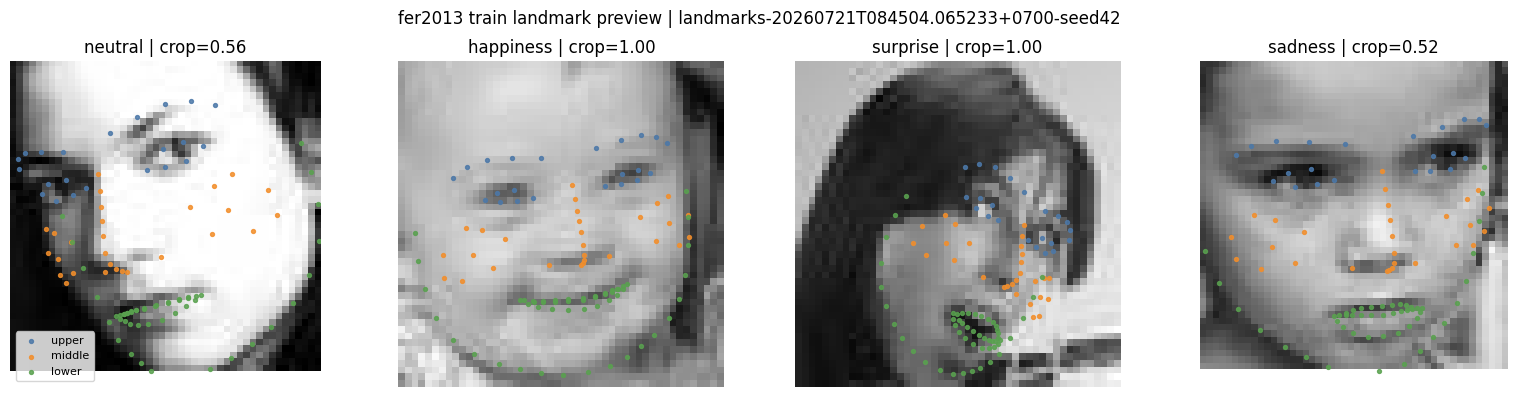

Saved: /home/jupyter-hault/EmotionCLIP-ReID/outputs/landmark_build/landmarks-20260721T084504.065233+0700-seed42/fer2013_landmark_failed_preview.png (8 failed samples shown)


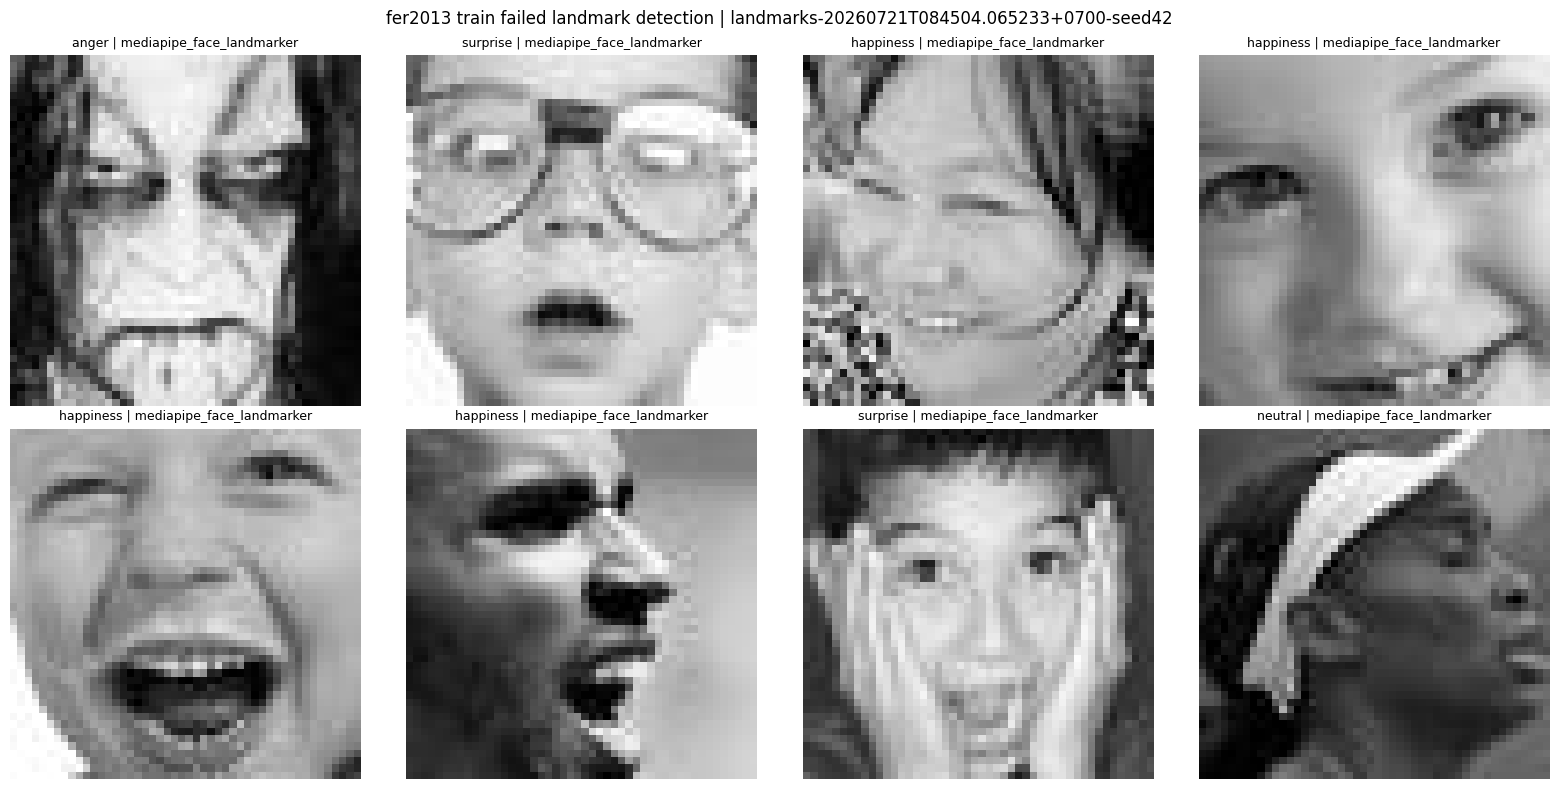

Saved: /home/jupyter-hault/EmotionCLIP-ReID/outputs/landmark_build/landmarks-20260721T084504.065233+0700-seed42/rafdb_landmark_preview.png


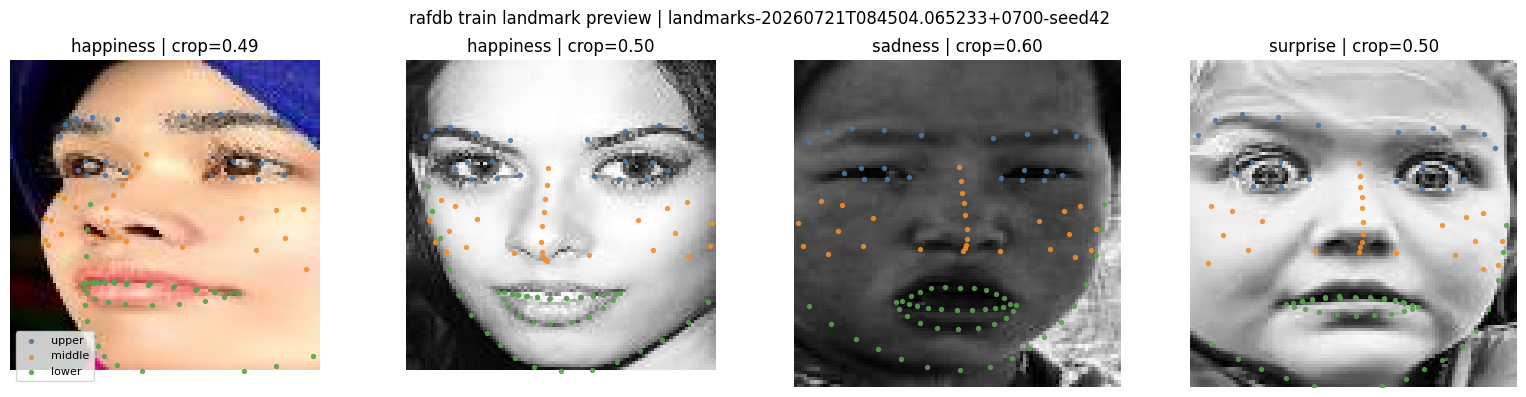

Saved: /home/jupyter-hault/EmotionCLIP-ReID/outputs/landmark_build/landmarks-20260721T084504.065233+0700-seed42/rafdb_landmark_failed_preview.png (8 failed samples shown)


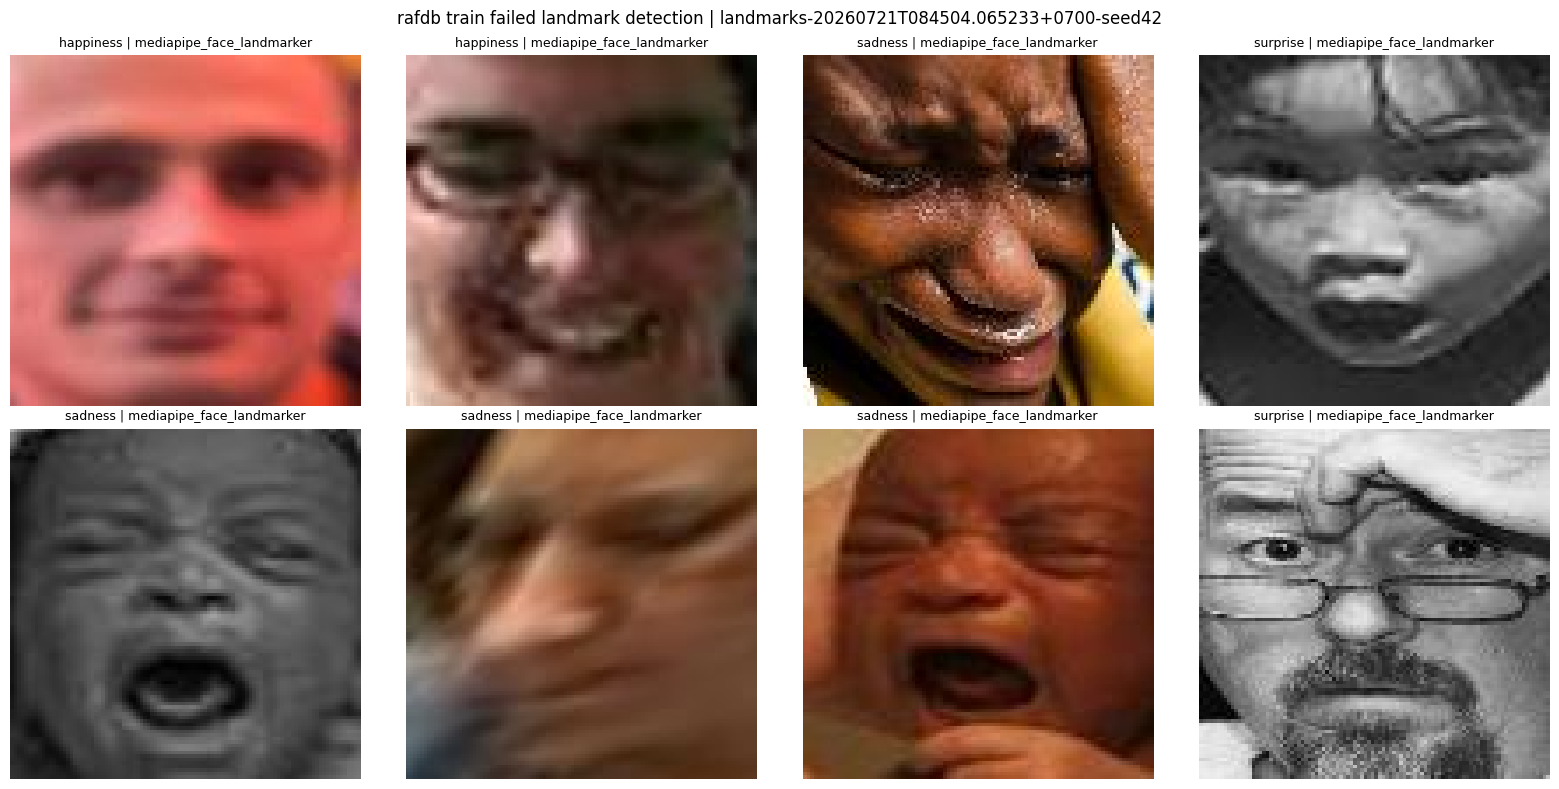

622

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from datasets.anatomy import MEDIAPIPE_GROUPS, REGION_GROUPS, load_anatomy_artifact
from datasets.emotion_manifest import load_emotion_manifest

region_colors = {'upper': '#4C78A8', 'middle': '#F28E2B', 'lower': '#59A14F'}
preview_paths = {}

for name, spec in DATASETS.items():
    if not enabled[name]:
        continue
    samples = load_emotion_manifest(
        str(spec['output_manifest']), root_dir=str(spec['root_dir']), split='train'
    )
    selected = []
    failed_selected = []
    for sample in samples:
        artifact = load_anatomy_artifact(sample.landmark_path) if sample.landmark_path else None
        if artifact and (artifact.get('detector') or {}).get('detected'):
            if len(selected) < 4:
                selected.append((sample, artifact))
        elif len(failed_selected) < 8:
            failed_selected.append((sample, artifact))
        if len(selected) >= 4 and len(failed_selected) >= 8:
            break

    fig, axes = plt.subplots(
        1, max(1, len(selected)), figsize=(4 * max(1, len(selected)), 4)
    )
    axes = np.atleast_1d(axes).ravel()
    if not selected:
        axes[0].text(0.5, 0.5, 'No detected landmark sample', ha='center', va='center')
        axes[0].axis('off')
    for ax, (sample, artifact) in zip(axes, selected):
        image = Image.open(sample.image_path).convert('RGB')
        ax.imshow(image)
        width, height = image.size
        landmarks = artifact.get('landmarks') or []
        for region, groups in REGION_GROUPS.items():
            indices = sorted({index for group in groups for index in MEDIAPIPE_GROUPS[group]})
            points = [
                landmarks[index]
                for index in indices
                if index < len(landmarks) and landmarks[index].get('valid', True)
            ]
            if points:
                ax.scatter(
                    [point['x'] * width for point in points],
                    [point['y'] * height for point in points],
                    s=8, alpha=0.85, label=region, color=region_colors[region]
                )
        ax.set_title(f'{sample.emotion} | crop={artifact.get("crop_quality", 0):.2f}')
        ax.axis('off')
    if selected:
        axes[0].legend(loc='lower left', fontsize=8)
    fig.suptitle(f'{name} train landmark preview | {LANDMARK_RUN_ID}')
    plt.tight_layout()
    preview_path = LANDMARK_RUN_DIR / f'{name}_landmark_preview.png'
    fig.savefig(preview_path, dpi=180, bbox_inches='tight')
    preview_paths[name] = str(preview_path)
    print('Saved:', preview_path)
    plt.show()

    failed_count = len(failed_selected)
    failed_cols = min(4, max(1, failed_count))
    failed_rows = max(1, int(np.ceil(failed_count / failed_cols)))
    fig, axes = plt.subplots(
        failed_rows, failed_cols, figsize=(4 * failed_cols, 4 * failed_rows)
    )
    axes = np.atleast_1d(axes).ravel()
    if not failed_selected:
        axes[0].text(0.5, 0.5, 'No failed landmark sample', ha='center', va='center')
        axes[0].axis('off')
    for ax, (sample, artifact) in zip(axes, failed_selected):
        image = Image.open(sample.image_path).convert('RGB')
        ax.imshow(image)
        detector_name = ((artifact or {}).get('detector') or {}).get('name', 'no artifact')
        ax.set_title(f'{sample.emotion} | {detector_name}', fontsize=9)
        ax.axis('off')
    for ax in axes[failed_count:]:
        ax.axis('off')
    fig.suptitle(f'{name} train failed landmark detection | {LANDMARK_RUN_ID}')
    plt.tight_layout()
    failed_preview_path = LANDMARK_RUN_DIR / f'{name}_landmark_failed_preview.png'
    fig.savefig(failed_preview_path, dpi=180, bbox_inches='tight')
    preview_paths[f'{name}_failed'] = str(failed_preview_path)
    print(f'Saved: {failed_preview_path} ({failed_count} failed samples shown)')
    plt.show()

(LANDMARK_RUN_DIR / 'preview_summary.json').write_text(
    json.dumps(preview_paths, indent=2, ensure_ascii=False), encoding='utf-8'
)


## 6. Training handoff

Sau khi cell trên thành công, hai notebook train dùng các manifest sau:

- `data/hf_fer2013/manifest_anatomy.jsonl`
- `data/RAF-DB/manifest_anatomy.jsonl`

Không bật `FORCE_REBUILD` trong notebook train; chỉ chạy lại notebook này khi dataset, model hoặc tham số landmark thay đổi.
